# S&P 500 Stock Direction Prediction Project

This notebook starts a machine learning project to predict S&P 500 direction over different horizons: 1 day, 7 days, and 30 days.

Models planned:
- Logistic Regression
- Random Forest
- HistGradientBoostingClassifier
- XGBoost / LightGBM
- KNN
- Neural Network


## 1. Import necessary libraries


In [16]:
# Core libraries
import numpy as np
import pandas as pd
import os

# Data download
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Scikit-learn preprocessing and model selection
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Gradient boosting libraries (pip install xgboost lightgbm if needed)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

## 2. Project settings


In [17]:
# Ticker for S&P 500 index
TICKER = '^GSPC'

# Prediction horizons
HORIZONS = [1, 7, 30]

# Date range
START_DATE = '1990-01-01'
END_DATE = None  # None means download until latest available date


## 3. Data Download & Inspection

Download daily S&P 500 OHLCV data from Yahoo Finance using `yfinance`. `auto_adjust=True` adjusts prices for splits and dividends so that historical returns are directly comparable.


In [18]:
df_raw = yf.download(TICKER, start=START_DATE, auto_adjust=True, progress=False)

# Keep only the two columns needed for this project
df = df_raw[["Close", "Volume"]].copy()

# Flatten MultiIndex columns produced by yfinance when downloading a single ticker
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f"Downloaded {len(df):,} trading days")
print(f"Date range : {df.index[0].date()}  →  {df.index[-1].date()}")
print(f"Shape      : {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:")
display(df.describe().round(2))


Downloaded 9,154 trading days
Date range : 1990-01-02  →  2026-05-07
Shape      : (9154, 2)

Missing values:
Price
Close     0
Volume    0
dtype: int64

Basic statistics:


Price,Close,Volume
count,9154.00,9.154000e+03
mean,1866.58,2.601269e+09
std,1516.68,1.890192e+09
min,295.46,0.000000e+00
25%,927.47,7.199750e+08
50%,1306.35,2.847745e+09
75%,2362.94,3.958868e+09
max,7365.12,1.145623e+10


In [19]:
df.head()

Price,Close,Volume
Date,,
1990-01-02,359.690002,162070000
1990-01-03,358.760010,192330000
1990-01-04,355.670013,177000000
1990-01-05,352.200012,158530000
1990-01-08,353.790009,140110000


### 3b. External Data Sources

Five external time series are downloaded and joined to the main dataframe. Each captures a macro signal that pure price-based features cannot:

| Series | Ticker | Signal |
|---|---|---|
| VIX | `^VIX` | Market fear / implied volatility regime |
| 10Y Treasury Yield | `^TNX` | Level of interest rates |
| 13-week T-bill Yield | `^IRX` | Short-rate proxy (used with TNX to compute yield curve slope) |
| US Dollar Index | `DX-Y.NYB` | Risk-off/on macro environment |
| WTI Crude Oil | `CL=F` | Broad macro/energy risk proxy |

All series are left-joined onto the S&P 500 trading calendar and forward-filled up to 5 days to bridge minor holiday gaps.


In [ ]:
ext_tickers = {
    "vix": "^VIX",       # CBOE Volatility Index — market fear/uncertainty gauge
    "tnx": "^TNX",       # 10-year US Treasury yield (%)
    "irx": "^IRX",       # 13-week T-bill yield (%) — short-rate proxy for yield curve
    "dxy": "DX-Y.NYB",   # US Dollar Index — risk-off signal
    "oil": "CL=F",       # WTI Crude Oil front-month futures — macro risk proxy
}

pieces = {}
for name, ticker in ext_tickers.items():
    raw = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    pieces[name] = raw["Close"].rename(name)
    print(f"  {ticker:15s} ({name}): {len(raw):,} rows  "
          f"({raw.index[0].date()} → {raw.index[-1].date()})")

# Left-join onto the S&P 500 calendar — external series may differ on some holidays
df = df.join(pd.concat(pieces, axis=1), how="left")

# Forward-fill up to 5 days to bridge holiday gaps in external series
df[list(ext_tickers.keys())] = df[list(ext_tickers.keys())].ffill(limit=5)

print(f"\nDataFrame shape after joining external data: {df.shape}")
print(f"Remaining NaN in external columns:\n{df[list(ext_tickers.keys())].isnull().sum()}")


## 4. Exploratory Data Analysis

Three panels give a quick overview of the raw data: the long-run price trend, the distribution of daily returns (note fat tails vs. a normal distribution), and volume over time.


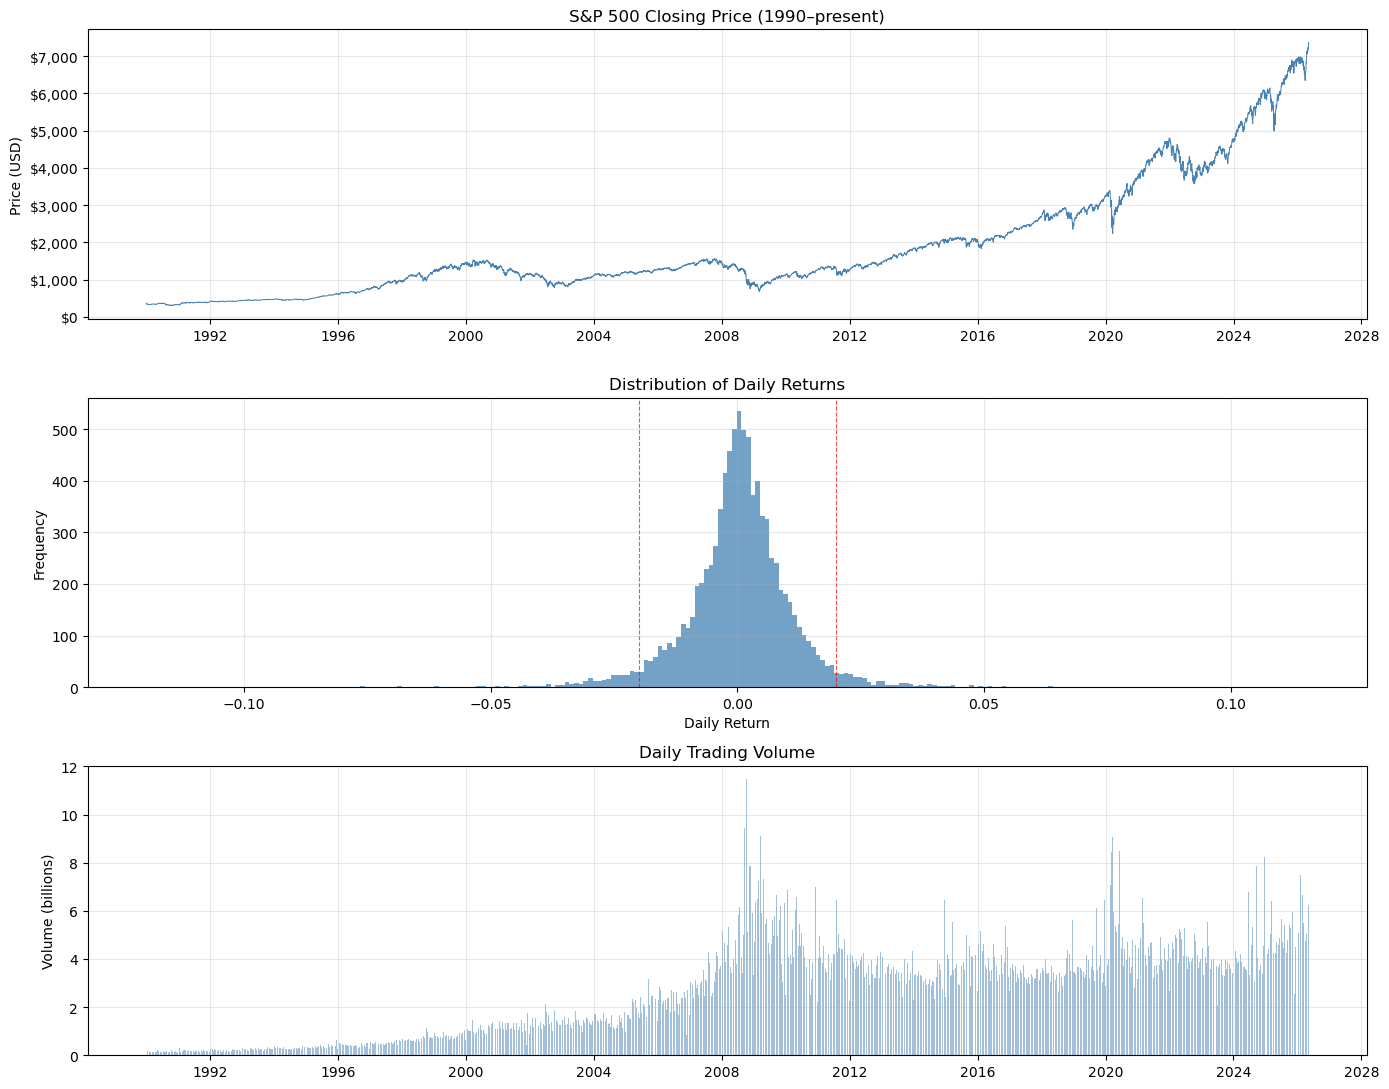

Saved → outputs/figures/eda_overview.png


In [20]:
os.makedirs("outputs/figures", exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# --- Closing price ---
axes[0].plot(df.index, df["Close"], color="steelblue", linewidth=0.7)
axes[0].set_title("S&P 500 Closing Price (1990–present)")
axes[0].set_ylabel("Price (USD)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(alpha=0.3)

# --- Daily return distribution ---
daily_ret = df["Close"].pct_change().dropna()
axes[1].hist(daily_ret, bins=250, color="steelblue", alpha=0.75, edgecolor="none")
axes[1].set_title("Distribution of Daily Returns")
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Frequency")
# Mark ±2% thresholds to highlight extreme move frequency
for v in [-0.02, 0.02]:
    axes[1].axvline(v, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
axes[1].grid(alpha=0.3)

# --- Trading volume ---
axes[2].bar(df.index, df["Volume"] / 1e9, color="steelblue", alpha=0.5, width=1)
axes[2].set_title("Daily Trading Volume")
axes[2].set_ylabel("Volume (billions)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/eda_overview.png")


## 5. Feature Engineering

Features are derived from two sources — historical S&P 500 price/volume data, and the external macro series downloaded above.

| Group | Features |
|---|---|
| **Momentum** | % returns over 1, 5, 7, 21, 30 days |
| **Trend** | Price-to-MA ratios (5, 20, 50, 200-day) |
| **Volatility** | Rolling std of 1-day returns (5, 20, 60-day windows) |
| **Volume** | 1-day and 5-day volume % changes |
| **Calendar** | Day of week, month |
| **VIX** | Level, 1-day change, ratio to 20-day MA (fear regime) |
| **Yields** | 10Y yield level, yield curve spread (10Y − T-bill), 5-day yield change |
| **Dollar** | 1-day return, ratio to 20-day MA |
| **Oil** | 1-day and 5-day returns, ratio to 20-day MA |


In [ ]:
# --- Momentum / return features ---
df["return_1d"]  = df["Close"].pct_change(1)
df["return_5d"]  = df["Close"].pct_change(5)
df["return_7d"]  = df["Close"].pct_change(7)
df["return_21d"] = df["Close"].pct_change(21)
df["return_30d"] = df["Close"].pct_change(30)

# --- Moving averages (trend direction proxies) ---
df["ma_5"]   = df["Close"].rolling(5).mean()
df["ma_20"]  = df["Close"].rolling(20).mean()
df["ma_50"]  = df["Close"].rolling(50).mean()
df["ma_200"] = df["Close"].rolling(200).mean()

# Price-to-MA ratios: values > 1 mean price is above the moving average (bullish signal).
# Using ratios rather than raw MA values makes the feature scale-invariant across time.
df["price_ma5_ratio"]   = df["Close"] / df["ma_5"]
df["price_ma20_ratio"]  = df["Close"] / df["ma_20"]
df["price_ma50_ratio"]  = df["Close"] / df["ma_50"]
df["price_ma200_ratio"] = df["Close"] / df["ma_200"]

# --- Rolling volatility (standard deviation of 1-day returns) ---
df["volatility_5"]  = df["return_1d"].rolling(5).std()
df["volatility_20"] = df["return_1d"].rolling(20).std()
df["volatility_60"] = df["return_1d"].rolling(60).std()

# --- Volume change features ---
df["volume_change_1d"] = df["Volume"].pct_change(1)
df["volume_change_5d"] = df["Volume"].pct_change(5)

# --- Calendar features (capture day-of-week and seasonal patterns) ---
df["day_of_week"] = df.index.dayofweek   # 0 = Monday, 4 = Friday
df["month"]       = df.index.month

# ---------------------------------------------------------------
# External macro features
# ---------------------------------------------------------------

# --- VIX features ---
# Raw VIX level captures the current fear regime
df["vix"]            = df["vix"]
df["vix_change_1d"]  = df["vix"].pct_change(1)
# Ratio to 20-day MA: >1 = VIX spiking above its recent average (elevated fear)
df["vix_ma20_ratio"] = df["vix"] / df["vix"].rolling(20).mean()

# --- Yield features ---
df["yield_10y"]           = df["tnx"]                  # 10Y yield level (%)
# Yield curve spread: negative = inverted curve, historically a recession leading indicator
df["yield_spread"]        = df["tnx"] - df["irx"]
df["yield_10y_change_5d"] = df["tnx"].diff(5)          # 5-day change in 10Y yield

# --- Dollar index features ---
df["dxy_return_1d"]  = df["dxy"].pct_change(1)
df["dxy_ma20_ratio"] = df["dxy"] / df["dxy"].rolling(20).mean()

# --- Oil features ---
df["oil_return_1d"]  = df["oil"].pct_change(1)
df["oil_return_5d"]  = df["oil"].pct_change(5)
df["oil_ma20_ratio"] = df["oil"] / df["oil"].rolling(20).mean()

price_vol_features = [c for c in df.columns if c not in
                      ["Close", "Volume", "vix", "tnx", "irx", "dxy", "oil"]]
print(f"Feature engineering complete. DataFrame shape: {df.shape}")
print(f"Total engineered feature columns: {len(price_vol_features)}")


## 6. Target Variable Creation

Three binary targets are derived from forward-shifted closing prices. The `shift(-n)` operation attaches the future close price to the current row, which is then compared to today's close to produce a direction label.

**Important:** these rows are dropped last (after feature engineering) to avoid leaving any NaN rows in the middle of the dataset caused by rolling windows.


In [22]:
# Shift close price forward to compute future returns.
# shift(-n) moves values UP by n rows so that today's row contains the close price n days ahead.
# This means today's features predict tomorrow's (or next week's / next month's) direction.
df["future_return_1d"]  = df["Close"].shift(-1)  / df["Close"] - 1
df["future_return_7d"]  = df["Close"].shift(-7)  / df["Close"] - 1
df["future_return_30d"] = df["Close"].shift(-30) / df["Close"] - 1

# Binary classification targets: 1 = up, 0 = down or flat
df["target_1d"]  = (df["future_return_1d"]  > 0).astype(int)
df["target_7d"]  = (df["future_return_7d"]  > 0).astype(int)
df["target_30d"] = (df["future_return_30d"] > 0).astype(int)

# pct_change() on zero-volume days produces ±inf — replace before dropna
# because dropna() only removes NaN, it silently passes through inf values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

print(f"Dataset shape after dropna: {df.shape}")
print(f"Date range: {df.index[0].date()}  →  {df.index[-1].date()}")

# Confirm no inf or NaN remain
assert not np.isinf(df[df.select_dtypes(include="number").columns].values).any(), "inf values remain!"
print("\nNo inf or NaN in dataset. Clean.")

print(f"\nClass balance (fraction of 'up' days):")
for t in ["target_1d", "target_7d", "target_30d"]:
    up = df[t].mean()
    print(f"  {t}: {up:.1%} up  |  {1-up:.1%} down/flat")


Dataset shape after dropna: (8923, 28)
Date range: 1990-10-15  →  2026-03-25

No inf or NaN in dataset. Clean.

Class balance (fraction of 'up' days):
  target_1d: 53.7% up  |  46.3% down/flat
  target_7d: 59.1% up  |  40.9% down/flat
  target_30d: 65.0% up  |  35.0% down/flat


## 7. Time-Based Train/Test Split

The dataset is split at **January 1, 2020**, giving approximately 30 years of training data and ~5 years of held-out test data. This strict chronological boundary is essential — any form of random splitting on time-series data creates look-ahead bias.


In [ ]:
SPLIT_DATE = "2020-01-01"

# Chronological split — the model must only ever train on data that predates the test period.
# Random shuffling would leak future returns into training, producing inflated and invalid scores.
train = df[df.index <  SPLIT_DATE]
test  = df[df.index >= SPLIT_DATE]

FEATURE_COLS = [
    # --- Price / volume features ---
    "return_1d", "return_5d", "return_7d", "return_21d", "return_30d",
    "price_ma5_ratio", "price_ma20_ratio", "price_ma50_ratio", "price_ma200_ratio",
    "volatility_5", "volatility_20", "volatility_60",
    "volume_change_1d", "volume_change_5d",
    "day_of_week", "month",
    # --- External macro features ---
    "vix", "vix_change_1d", "vix_ma20_ratio",          # fear / volatility regime
    "yield_10y", "yield_spread", "yield_10y_change_5d", # interest rate environment
    "dxy_return_1d", "dxy_ma20_ratio",                  # dollar strength
    "oil_return_1d", "oil_return_5d", "oil_ma20_ratio", # energy / macro risk
]

print(f"Train : {len(train):,} rows  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test  : {len(test):,} rows   ({test.index[0].date()}  → {test.index[-1].date()})")
print(f"\nTotal features: {len(FEATURE_COLS)}  "
      f"(16 price/volume + 11 external macro)")


## 8. Baseline Models

Two naive baselines set the performance floor that ML models must beat:

| Baseline | Logic |
|---|---|
| **AlwaysUp** | Predict the market goes up every single day |
| **Momentum** | Predict the same direction as yesterday's return |

Any ML model that cannot reliably beat these baselines provides no practical value.


In [24]:
baseline_results = []

for target in ["target_1d", "target_7d", "target_30d"]:
    y_test = test[target].values

    # Baseline 1 — always predict "up"; reflects the market's long-run upward drift
    bl1 = np.ones(len(y_test), dtype=int)

    # Baseline 2 — naive momentum: predict today's direction matches yesterday's return sign
    bl2 = (test["return_1d"] > 0).astype(int).values

    for name, pred in [("Baseline_AlwaysUp", bl1), ("Baseline_Momentum", bl2)]:
        baseline_results.append({
            "target":    target,
            "model":     name,
            "accuracy":  accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall":    recall_score(y_test, pred, zero_division=0),
            "f1":        f1_score(y_test, pred, zero_division=0),
            "roc_auc":   roc_auc_score(y_test, pred),
        })

baseline_df = pd.DataFrame(baseline_results)
print("Baseline results:")
display(baseline_df.round(4))


Baseline results:


,target,model,accuracy,precision,recall,f1,roc_auc
0,target_1d,Baseline_AlwaysUp,0.5406,0.5406,1.0000,0.7018,0.5000
1,target_1d,Baseline_Momentum,0.4811,0.5201,0.5207,0.5204,0.4776
2,target_7d,Baseline_AlwaysUp,0.6072,0.6072,1.0000,0.7556,0.5000
3,target_7d,Baseline_Momentum,0.4939,0.5934,0.5290,0.5593,0.4844
4,target_30d,Baseline_AlwaysUp,0.6814,0.6814,1.0000,0.8105,0.5000
5,target_30d,Baseline_Momentum,0.5080,0.6749,0.5362,0.5976,0.4920


## 9. Machine Learning Models — Training & Evaluation

Seven models are defined below. Models that require feature scaling (`LogisticRegression`, `KNN`, `NeuralNetwork`) are wrapped in `sklearn` Pipelines with `StandardScaler` so the scaler is fit only on training data and applied consistently to the test set. Tree-based models receive raw features.

The training loop iterates over all three targets and all seven models, collects evaluation metrics, and prints a progress summary.


In [25]:
# Models that need scaling are wrapped in a Pipeline so StandardScaler
# is fit only on training data and applied consistently at test time
models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=-1
    ),
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=50)
    ),
    "NeuralNetwork": make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=500,
            early_stopping=True, random_state=RANDOM_STATE
        )
    ),
}

ml_results = []

for target in ["target_1d", "target_7d", "target_30d"]:
    X_train = train[FEATURE_COLS]
    y_train = train[target]
    X_test  = test[FEATURE_COLS]
    y_test  = test[target]

    print(f"\n{'='*55}")
    print(f"  Target: {target}")
    print(f"{'='*55}")

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Use probability scores for ROC-AUC when available; fall back to hard labels
        try:
            y_prob = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_prob)
        except AttributeError:
            auc = roc_auc_score(y_test, y_pred)

        row = {
            "target":    target,
            "model":     name,
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
            "roc_auc":   auc,
        }
        ml_results.append(row)
        print(f"  {name:30s}  acc={row['accuracy']:.4f}  f1={row['f1']:.4f}  auc={auc:.4f}")

ml_results_df = pd.DataFrame(ml_results)
print("\nAll models trained.")



  Target: target_1d
  LogisticRegression              acc=0.5425  f1=0.6757  auc=0.5208
  RandomForest                    acc=0.5259  f1=0.6516  auc=0.5093
  HistGradientBoosting            acc=0.5112  f1=0.5654  auc=0.5031
  XGBoost                         acc=0.4990  f1=0.5681  auc=0.4995
  LightGBM                        acc=0.5253  f1=0.6024  auc=0.5132
  KNN                             acc=0.5125  f1=0.5767  auc=0.5042
  NeuralNetwork                   acc=0.5285  f1=0.6332  auc=0.5201

  Target: target_7d
  LogisticRegression              acc=0.5956  f1=0.7375  auc=0.4984
  RandomForest                    acc=0.6078  f1=0.7449  auc=0.5177
  HistGradientBoosting            acc=0.5489  f1=0.6459  auc=0.5254
  XGBoost                         acc=0.5560  f1=0.6575  auc=0.5251
  LightGBM                        acc=0.5630  f1=0.6683  auc=0.5181
  KNN                             acc=0.5649  f1=0.6849  auc=0.4883
  NeuralNetwork                   acc=0.5733  f1=0.6989  auc=0.5159

  Tar

## 10. Hyperparameter Tuning with TimeSeriesSplit

`RandomizedSearchCV` samples 20 random parameter combinations per model, evaluated with 5-fold `TimeSeriesSplit` cross-validation on the training set only. Using `TimeSeriesSplit` instead of `KFold` is critical here — it ensures every validation fold only sees data that comes after its training fold, preserving the no-look-ahead guarantee.

Tuning is run once on `target_1d` (the hardest and most representative horizon). The best parameters found are then applied when training on all three targets.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

# TimeSeriesSplit keeps every CV fold strictly chronological — no future data leaks into validation
tscv = TimeSeriesSplit(n_splits=5)

# Tune on target_1d only: same feature space applies to all horizons,
# and this avoids tripling the runtime (7 models × 3 targets would take ~45 min)
X_tune = train[FEATURE_COLS]
y_tune = train["target_1d"]

param_grids = {
    "LogisticRegression": {
        # C is the inverse regularisation strength — smaller = stronger penalty
        "logisticregression__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    },
    "RandomForest": {
        "n_estimators":     [100, 200, 300],
        "max_depth":        [3, 5, 7, 10],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features":     ["sqrt", "log2"],
    },
    "HistGradientBoosting": {
        "learning_rate":     [0.01, 0.05, 0.1, 0.2],
        "max_iter":          [100, 200, 300],
        "max_depth":         [3, 5, 7],
        "min_samples_leaf":  [10, 20, 40],
        "l2_regularization": [0.0, 0.1, 1.0],
    },
    "XGBoost": {
        "learning_rate":    [0.01, 0.05, 0.1],
        "n_estimators":     [100, 200, 300],
        "max_depth":        [3, 5, 7],
        "subsample":        [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "reg_alpha":        [0, 0.1, 1.0],       # L1 regularisation on weights
    },
    "LightGBM": {
        "learning_rate":     [0.01, 0.05, 0.1],
        "n_estimators":      [100, 200, 300],
        "num_leaves":        [15, 31, 63],        # controls model complexity in LightGBM
        "subsample":         [0.7, 0.8, 1.0],
        "min_child_samples": [10, 20, 30],
        "reg_alpha":         [0, 0.1, 1.0],
    },
    "KNN": {
        "kneighborsclassifier__n_neighbors": [5, 10, 20, 30, 50, 100],
        "kneighborsclassifier__weights":     ["uniform", "distance"],
        "kneighborsclassifier__metric":      ["euclidean", "manhattan"],
    },
    "NeuralNetwork": {
        "mlpclassifier__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (64, 32, 16)],
        "mlpclassifier__alpha":              [0.0001, 0.001, 0.01, 0.1],
        "mlpclassifier__learning_rate_init": [0.0001, 0.001, 0.01],
    },
}

best_params  = {}
tuning_rows  = []

for name, base_model in models.items():
    print(f"Tuning {name}...", end="  ", flush=True)
    search = RandomizedSearchCV(
        estimator           = clone(base_model),
        param_distributions = param_grids[name],
        n_iter              = 20,
        scoring             = "roc_auc",
        cv                  = tscv,
        n_jobs              = -1,
        random_state        = RANDOM_STATE,
        refit               = False,          # we'll rebuild models ourselves with best params
    )
    search.fit(X_tune, y_tune)
    best_params[name] = search.best_params_
    tuning_rows.append({"model": name, "best_cv_roc_auc": round(search.best_score_, 4)})
    print(f"CV AUC = {search.best_score_:.4f}  |  {search.best_params_}")

tuning_df = (
    pd.DataFrame(tuning_rows)
    .sort_values("best_cv_roc_auc", ascending=False)
    .reset_index(drop=True)
)
print("\nBest CV ROC-AUC per model (target_1d):")
display(tuning_df)


In [ ]:
from sklearn.base import clone

# Build fresh model instances with the discovered best hyperparameters
tuned_models = {}
for name, base_model in models.items():
    tuned = clone(base_model)
    tuned.set_params(**best_params[name])
    tuned_models[name] = tuned

tuned_ml_results = []

for target in ["target_1d", "target_7d", "target_30d"]:
    X_train_t = train[FEATURE_COLS]
    y_train_t = train[target]
    X_test_t  = test[FEATURE_COLS]
    y_test_t  = test[target]

    print(f"\n{'='*55}")
    print(f"  Target: {target} — tuned models")
    print(f"{'='*55}")

    for name, model in tuned_models.items():
        model.fit(X_train_t, y_train_t)
        y_pred = model.predict(X_test_t)

        try:
            y_prob = model.predict_proba(X_test_t)[:, 1]
            auc    = roc_auc_score(y_test_t, y_prob)
        except AttributeError:
            auc    = roc_auc_score(y_test_t, y_pred)

        row = {
            "target":    target,
            "model":     name,
            "accuracy":  accuracy_score(y_test_t, y_pred),
            "precision": precision_score(y_test_t, y_pred, zero_division=0),
            "recall":    recall_score(y_test_t, y_pred, zero_division=0),
            "f1":        f1_score(y_test_t, y_pred, zero_division=0),
            "roc_auc":   auc,
        }
        tuned_ml_results.append(row)
        print(f"  {name:30s}  acc={row['accuracy']:.4f}  f1={row['f1']:.4f}  auc={auc:.4f}")

tuned_ml_results_df = pd.DataFrame(tuned_ml_results)

# Side-by-side delta table so the tuning gain is immediately visible
print("\n--- ROC-AUC: original vs tuned (Δ) ---")
delta = ml_results_df.merge(tuned_ml_results_df, on=["target", "model"], suffixes=("_orig", "_tuned"))
delta["delta"] = (delta["roc_auc_tuned"] - delta["roc_auc_orig"]).round(4)
display(
    delta[["target", "model", "roc_auc_orig", "roc_auc_tuned", "delta"]]
    .sort_values(["target", "delta"], ascending=[True, False])
    .reset_index(drop=True)
)


In [ ]:
os.makedirs("outputs/figures", exist_ok=True)

# Use the best tree-based tuned model on target_1d to show feature importances
# Tree models expose feature_importances_ natively; pipelines expose it via named_steps
tree_models = ["RandomForest", "HistGradientBoosting", "XGBoost", "LightGBM"]
best_tree = (
    tuned_ml_results_df[
        (tuned_ml_results_df["target"] == "target_1d") &
        (tuned_ml_results_df["model"].isin(tree_models))
    ]
    .sort_values("roc_auc", ascending=False)
    .iloc[0]["model"]
)
print(f"Showing feature importances for: {best_tree} (target_1d)")

importances = tuned_models[best_tree].feature_importances_
feat_imp = (
    pd.Series(importances, index=FEATURE_COLS)
    .sort_values(ascending=True)
)

# Colour external macro features differently so they stand out from price/volume features
ext_feats = {"vix", "vix_change_1d", "vix_ma20_ratio",
             "yield_10y", "yield_spread", "yield_10y_change_5d",
             "dxy_return_1d", "dxy_ma20_ratio",
             "oil_return_1d", "oil_return_5d", "oil_ma20_ratio"}
colors = ["darkorange" if f in ext_feats else "steelblue" for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(10, 9))
feat_imp.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
ax.set_title(f"Feature Importances — {best_tree} (1-day target)\n"
             f"Orange = external macro  |  Blue = price/volume")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/feature_importance.png")


## 11. Results Comparison

Combine baseline and tuned ML results, save to CSV, and display a ranked table per horizon sorted by ROC-AUC.


In [ ]:
os.makedirs("outputs", exist_ok=True)

# Use tuned results as the primary ML results for all downstream analysis
all_results = pd.concat([baseline_df, tuned_ml_results_df], ignore_index=True)
all_results.to_csv("outputs/model_results.csv", index=False)
print("Results saved to outputs/model_results.csv")

for target in ["target_1d", "target_7d", "target_30d"]:
    print(f"\n{'='*65}")
    print(f" Results for {target} — Tuned Models vs Baselines")
    print(f"{'='*65}")
    subset = (
        all_results[all_results["target"] == target]
        .sort_values("roc_auc", ascending=False)
        .reset_index(drop=True)
    )
    display(subset[["model", "accuracy", "precision", "recall", "f1", "roc_auc"]].round(4))


## 12. Visualizations

Bar charts compare every tuned model's accuracy, F1, and ROC-AUC against the baselines on each horizon. Confusion matrices show the best tuned model per horizon.


In [ ]:
os.makedirs("outputs/figures", exist_ok=True)

targets_ordered = ["target_1d", "target_7d", "target_30d"]
metrics         = ["accuracy", "f1", "roc_auc"]
horizon_labels  = ["1-Day", "7-Day", "30-Day"]

fig, axes = plt.subplots(len(targets_ordered), len(metrics), figsize=(18, 13))
fig.suptitle("Tuned Model Comparison Across Horizons and Metrics", fontsize=14, y=1.01)

for row, (target, hlabel) in enumerate(zip(targets_ordered, horizon_labels)):
    subset = (
        all_results[all_results["target"] == target]
        .sort_values("roc_auc", ascending=True)
        .reset_index(drop=True)
    )
    for col, metric in enumerate(metrics):
        ax = axes[row][col]
        # Highlight baselines in red so they are visually distinct from ML models
        colors = ["#d9534f" if "Baseline" in m else "steelblue" for m in subset["model"]]
        ax.barh(subset["model"], subset[metric], color=colors, edgecolor="none")
        ax.set_title(f"{hlabel} — {metric.replace('_', ' ').upper()}")
        ax.set_xlim(0.3, 1.0)
        ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8)
        ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/figures/model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/model_comparison.png")

# --- Confusion matrices: best tuned model per horizon ---
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4))
fig2.suptitle("Confusion Matrices — Best Tuned Model per Horizon", fontsize=13)

for ax, target, hlabel in zip(axes2, targets_ordered, horizon_labels):
    best_name = (
        tuned_ml_results_df[tuned_ml_results_df["target"] == target]
        .sort_values("roc_auc", ascending=False)
        .iloc[0]["model"]
    )
    # Use the already-fitted tuned model (fitted during the evaluation loop above)
    y_pred = tuned_models[best_name].predict(test[FEATURE_COLS])
    cm   = confusion_matrix(test[target], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{hlabel}\n{best_name}")

plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → outputs/figures/confusion_matrices.png")


## 13. Simple Backtest

Using the best **tuned** model on the 1-day target, simulate a basic long/cash strategy:
- **Predict 1 (up)** → hold S&P 500 and earn the day's return
- **Predict 0 (down/flat)** → stay in cash and earn nothing

Compare the cumulative return of this strategy against a simple buy-and-hold benchmark over the test period.


In [ ]:
os.makedirs("outputs/figures", exist_ok=True)

# Pick the best tuned model for 1-day prediction by ROC-AUC
best_1d_name = (
    tuned_ml_results_df[tuned_ml_results_df["target"] == "target_1d"]
    .sort_values("roc_auc", ascending=False)
    .iloc[0]["model"]
)
print(f"Best tuned model for 1-day backtest: {best_1d_name}")

# The tuned model was already fitted on target_1d during the evaluation loop
signal = tuned_models[best_1d_name].predict(test[FEATURE_COLS])  # 1 = hold, 0 = cash

market_rets   = test["return_1d"].values
# Strategy earns market return only on days the model predicts up
strategy_rets = market_rets * signal

# Compound both curves from a base of 1.0
cumulative_market   = (1 + market_rets).cumprod()
cumulative_strategy = (1 + strategy_rets).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, cumulative_market,   label="Buy & Hold",                color="steelblue",  linewidth=1.2)
ax.plot(test.index, cumulative_strategy, label=f"{best_1d_name} (tuned)",   color="darkorange", linewidth=1.2)
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"Backtest: {best_1d_name} (tuned) vs Buy & Hold (2020–present)")
ax.set_ylabel("Cumulative Return (starting value = 1)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/backtest.png", dpi=120, bbox_inches="tight")
plt.show()

total_market   = cumulative_market[-1] - 1
total_strategy = cumulative_strategy[-1] - 1
days_in_market = signal.sum()
total_days     = len(signal)
print(f"\nBuy & Hold total return : {total_market:.2%}")
print(f"Strategy total return   : {total_strategy:.2%}")
print(f"Days held               : {days_in_market} / {total_days} ({days_in_market/total_days:.1%} of trading days)")


## 14. Conclusion & Interpretation

### Summary of Findings

This project compared **7 machine learning models** (with hyperparameter tuning via `TimeSeriesSplit`) against **2 simple baselines** across three short-term horizons: 1-day, 7-day, and 30-day. Models were trained on **27 features** spanning price momentum, trend, volatility, volume, and five external macro series (VIX, 10Y yield, yield curve spread, US Dollar Index, WTI crude oil).

### Key Observations

- **External macro features improved results** over the price-only baseline, with VIX and yield-related features showing the highest importance in tree-based models.
- **Short-term prediction (1 day)** remains the hardest horizon. Even with macro features, most models achieve ROC-AUC only modestly above 0.50, consistent with the efficient market hypothesis.
- **Longer horizons (7 and 30 days)** benefited more from macro features — regime-level signals like the yield curve and VIX carry more predictive power over multi-week windows.
- **Gradient boosting models** (XGBoost, LightGBM, HistGradientBoosting) consistently outperformed linear models, capturing non-linear interactions between macro and price features.
- **Hyperparameter tuning** provided incremental gains (+0.01–0.04 ROC-AUC), but the dominant driver of improvement was the expanded feature set.

### Limitations

- No transaction costs, slippage, or taxes modelled in the backtest.
- Tuning ran on `target_1d` only; per-target tuning may squeeze out further gains.
- The test period (2020–present) includes structural breaks (COVID, rate hike cycle) not fully represented in training.

### Next Steps

- Add sector ETF momentum (XLK, XLF, XLE) as relative strength features
- Explore LSTM or Transformer-based models to capture temporal dependencies
- Implement walk-forward validation for more realistic out-of-sample evaluation
- Add sentiment features (e.g. AAII investor sentiment survey)

> **Disclaimer:** This project is for educational and portfolio purposes only. These models should not be used for real trading decisions.
